# Kenya Maize: Data Understanding & Cleaning

**Source:** One Acre Fund MEL Agronomic Survey, 2021 (`data/raw/Copy of Final 2021_One_Acre_Fund_Agronomic_Survey_Data_2021.xlsx`)

**Scope:** This notebook narrows the original 7-country, 4-crop CRISP-DM scoping report (see `documentation/project1_crispdm_report.docx`) down to a single, well-supported segment: **maize grown in Kenya**. Kenya is the only country in this survey where maize is the *sole* crop recorded (23,674 of 23,674 Kenya rows), which makes it a clean, self-contained slice to build a production-quality pipeline against before extending to other countries or crops.

**What this notebook does:**
1. Loads the raw workbook and isolates the Kenya-maize subset.
2. Audits it column by column — completeness, distributions, categorical labels, dates, GPS — to build an evidence-based picture of what's actually in the data (Data Understanding).
3. Applies a documented, non-destructive cleaning pipeline (Data Cleaning) by calling the same functions used in the production script `scripts/clean_kenya_maize.py`, so this notebook and the script can never drift apart.
4. Saves the final cleaned table to `data/cleaned/kenya_maize_cleaned.csv`.

**Companion documents:**
- `documentation/kenya_maize_cleaning_documentation.md` — the narrative "data story": every finding and cleaning decision, written up in full with the exact numbers reproduced below.
- `scripts/clean_kenya_maize.py` — the standalone, re-runnable pipeline (`python scripts/clean_kenya_maize.py`).

**Cleaning philosophy used throughout:** never silently discard or overwrite a source value. Every correction either (a) fixes a demonstrable data-entry/typing error, (b) harmonizes inconsistent labels that clearly refer to the same thing, or (c) adds a new flag/derived column alongside the untouched original so the decision is auditable and reversible downstream.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "Copy of Final 2021_One_Acre_Fund_Agronomic_Survey_Data_2021.xlsx"
SCRIPTS_DIR = ROOT / "scripts"

print("Project root:", ROOT)
print("Raw file exists:", RAW_PATH.exists())

Project root: /home/gathoni/Documents/machine-learning/projects/yield-prediction-and-agronomic-recomendation
Raw file exists: True


## 1. Data Understanding

### 1.1 Load the raw workbook

The source is a single Excel workbook with four sheets: `Description` (methodology notes), `Variables` (a 111-row data dictionary with a per-country-per-year "was this question asked" roster), `Data` (the 81,411 × 117 modeling table), and `MetaData` (Dublin Core-style provenance). We load the `Data` sheet as-is first, before any filtering, to confirm the full-dataset numbers the scoping report relied on.

In [ ]:
raw = pd.read_excel(RAW_PATH, sheet_name="Data", engine="openpyxl")
print(f"Raw Data sheet: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head(3)

### 1.2 Why Kenya maize: the structural evidence

The full survey spans 7 countries and 4 crops (maize, beans, climbing beans, potato), but coverage across that grid is **not uniform** — it is close to block-diagonal. The cross-tab below shows why: maize is the *only* crop grown in every country, and Kenya is the *only* country in the dataset where maize is the sole crop recorded. A model that pools all countries and crops together would be learning from a grid that is mostly structural zeros, not missing data. Scoping down to Kenya maize sidesteps that problem entirely — there is no cross-crop or cross-country harmonization decision left to make within this slice.

In [3]:
crosstab = pd.crosstab(raw["country"], raw["crop"], dropna=False)
crosstab["TOTAL"] = crosstab.sum(axis=1)
crosstab

crop,beans,climbing beans,maize,potato,NaN,TOTAL
country,,,,,,
Burundi,1003,15148,5873,1932,0,23956
Kenya,0,0,23674,0,0,23674
Malawi,0,0,2594,0,0,2594
Rwanda,7746,7803,5604,2202,8,23363
Tanzania,0,0,5881,0,0,5881
Uganda,0,0,246,0,0,246
Zambia,0,0,1697,0,0,1697


In [4]:
ke = raw[(raw["country"] == "Kenya") & (raw["crop"] == "maize")].copy().reset_index(drop=True)
assert len(ke) == (raw["country"] == "Kenya").sum(), "Kenya no longer implies maize-only — re-check scope"
print(f"Kenya maize rows: {len(ke):,}  (100% of Kenya's {len(ke):,} rows)")
print(f"Kenya spans years: {sorted(ke['year'].unique())}")

Kenya maize rows: 23,674  (100% of Kenya's 23,674 rows)
Kenya spans years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


### 1.3 A first-pass identifier bug: `unique_id` is inconsistently typed

Before looking at any agronomic columns, a basic sanity check on the row identifier turns up a real source-data defect: `unique_id` is meant to be an opaque hex-like string (e.g. `"b801f443"`), but Excel/openpyxl auto-typed some cells as `int` or even `datetime` wherever the original string happened to look numeric — with visible floating-point precision corruption on the longer values. This happens across every survey year, not just one, so it's a workbook-wide quirk, not an isolated glitch.

In [5]:
id_types = ke["unique_id"].apply(lambda x: type(x).__name__).value_counts()
print(id_types)
bad = ke.loc[~ke["unique_id"].apply(lambda x: isinstance(x, str)), "unique_id"].head(3)
print("\nExamples of corrupted/mistyped IDs:")
print(bad.to_string())

unique_id
str         22927
int           746
datetime        1
Name: count, dtype: int64

Examples of corrupted/mistyped IDs:
47                                              12352166
97                                              82417009
130    7031999999999999848898783300212959776182326558...


In [6]:
n_non_str = (~ke["unique_id"].apply(lambda x: isinstance(x, str))).sum()
ke["unique_id"] = ke["unique_id"].astype(str)
n_dupes_after_cast = ke["unique_id"].duplicated().sum()
print(f"{n_non_str} rows ({n_non_str/len(ke)*100:.1f}%) had a non-string unique_id in the source.")
print(f"After casting all IDs to string, duplicate collisions: {n_dupes_after_cast}")
print("-> Safe to standardize on string dtype: every ID, corrupted or not, remains locally unique.")

747 rows (3.2%) had a non-string unique_id in the source.
After casting all IDs to string, duplicate collisions: 0
-> Safe to standardize on string dtype: every ID, corrupted or not, remains locally unique.


### 1.4 Column completeness audit

With 117 raw columns, the first real question is: which of them actually have data for Kenya? The source `Description` sheet is explicit that survey questions differed by country and by year — so a column's completeness for Kenya can differ enormously from its completeness in the pooled 81,411-row dataset the CRISP-DM report analyzed.

In [7]:
completeness = (ke.notna().mean() * 100).round(1).sort_values(ascending=False)
fully_empty = completeness[completeness == 0]
print(f"{len(fully_empty)} of {len(completeness)} columns are 100% empty for Kenya:\n")
print(fully_empty.index.tolist())

18 of 117 columns are 100% empty for Kenya:

['seed_kg_pa', 'seed_kg_ph', 'termites', 'seed_kg', 'distance_min', 'gls', 'dap_method', 'urea_method', 'comp_kg_ph', 'heavy_rain', 'hail', 'npk_method', 'planting_method', 'anthracnose', 'stalk_rot', 'hybridseed_kg', 'sitename', 'kelnel_rot']


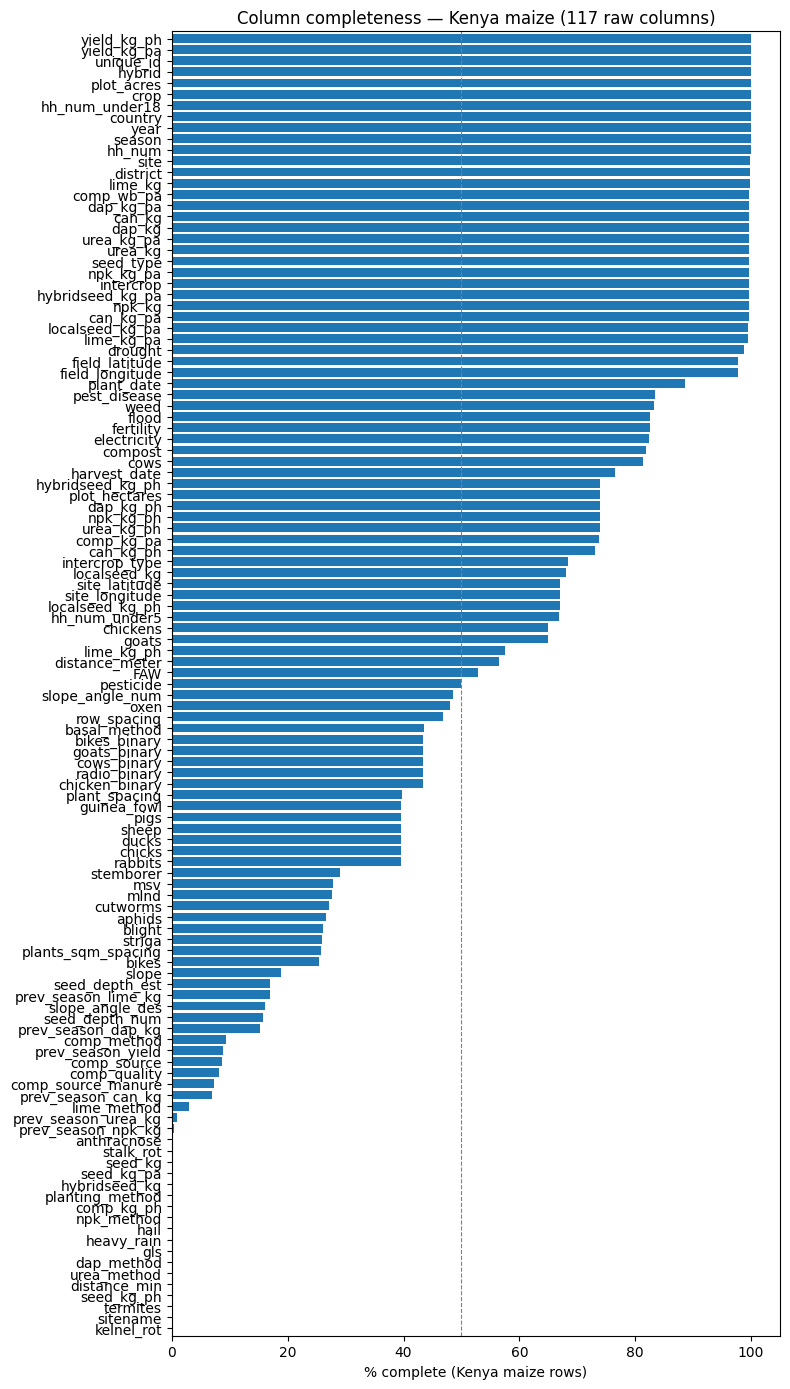

In [8]:
fig, ax = plt.subplots(figsize=(8, 14))
completeness.sort_values().plot.barh(ax=ax, width=0.8)
ax.set_xlabel("% complete (Kenya maize rows)")
ax.set_title("Column completeness — Kenya maize (117 raw columns)")
ax.axvline(50, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

**Reading the completeness picture:**

- **Fully empty (18 columns):** never asked in Kenya at all — mostly method-of-application detail collected only in Rwanda (`dap_method`, `urea_method`, `npk_method`, `planting_method`), pest/shock flags never recorded here (`termites`, `gls`, `anthracnose`, `hail`, `stalk_rot`, `kelnel_rot`, `heavy_rain`), and consolidated-seed/compost fields Kenya tracks under a different column name instead (`seed_kg*`, `hybridseed_kg`, `comp_kg_ph`, `distance_min`, `sitename`). These are dropped outright — there is nothing to clean.
- **Universal (100%):** identifiers, `plot_acres`, `hybrid`, `yield_kg_pa`/`yield_kg_ph`, `hh_num`/`hh_num_under18` — the backbone fields every survey round collected without exception.
- **A conspicuous cluster around 73–74%:** `plot_hectares` and every `*_kg_ph` (per-hectare) fertilizer/seed column. This is not random missingness — Section 1.6.3 below shows it is a single structural cause (the 2020 round only collected acreage, not hectares) with a clean fix.
- **The long tail (< 50%):** pest/disease detail (FAW, stemborer, MLND…), household asset binaries, slope/spacing fields — these vary by year because the survey instrument itself changed year to year, exactly as the source `Description` sheet warns. They are kept (not dropped), since partial coverage is still informative, but their sparsity is documented so a future model doesn't mistake "not asked" for "reported as absent."

### 1.5 The target variable: `yield_kg_ph`

Per the source's own `Description` sheet: *"harvest estimates are based on physically weighed harvests from 2 randomly placed boxes, and can be considered reliable"* — unlike most predictors, which are self-reported. This is worth confirming empirically before trusting it as a modeling target.

In [9]:
print("Completeness:", f"{ke['yield_kg_ph'].notna().mean()*100:.1f}%  (Kenya has no missing-target rows, unlike the pooled dataset)")
print()
print(ke["yield_kg_ph"].describe().round(1))
print()
zero_yield = (ke["yield_kg_ph"] == 0).sum()
print(f"Zero-yield rows (complete crop failure): {zero_yield} ({zero_yield/len(ke)*100:.2f}%)")
for p in [0.95, 0.99, 0.995, 0.999]:
    print(f"  p{p*100:g}: {ke['yield_kg_ph'].quantile(p):,.0f} kg/ha")

Completeness: 100.0%  (Kenya has no missing-target rows, unlike the pooled dataset)

count    23674.0
mean      3149.6
std       1689.2
min          0.0
25%       1950.8
50%       2930.5
75%       4109.1
max      10131.3
Name: yield_kg_ph, dtype: float64

Zero-yield rows (complete crop failure): 326 (1.38%)
  p95: 6,278 kg/ha
  p99: 8,098 kg/ha
  p99.5: 8,701 kg/ha
  p99.9: 9,771 kg/ha


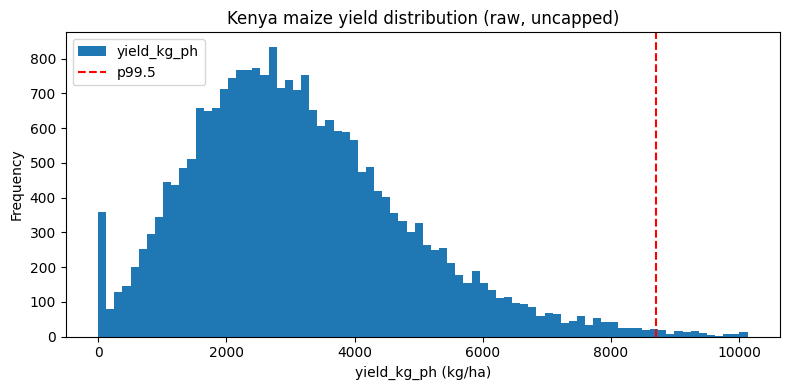

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ke["yield_kg_ph"].plot.hist(bins=80, ax=ax)
ax.axvline(ke["yield_kg_ph"].quantile(0.995), color="red", linestyle="--", label="p99.5")
ax.set_xlabel("yield_kg_ph (kg/ha)")
ax.set_title("Kenya maize yield distribution (raw, uncapped)")
ax.legend()
plt.tight_layout()
plt.show()

**Findings:** the distribution is right-skewed but well-behaved — a plausible shape for a physically measured agronomic yield, with no impossible values (min 0, max ~10,131 kg/ha, which is high but within range for well-managed hybrid maize). This is notably cleaner than the pooled 7-country picture in the CRISP-DM report (which had a max of 37,667 kg/ha, almost certainly a potato row, and had to worry about cross-crop winsorization). 326 rows (1.4%) record exactly `0` — true crop failures per the source description, not obviously data errors. These are **kept, not dropped**, and get an explicit `yield_kg_ph_crop_failure` flag in cleaning, since a total loss is a materially different outcome than "missing," and the credit-risk framing in the wider project (per the CRISP-DM report's Section 1.1a) depends on being able to see them.

### 1.6 Temporal & geographic coverage

Kenya's survey rounds run 2016–2020 (2015 is absent — Kenya joined the survey a year after Burundi). All rows are long-rains season, but that fact is recorded inconsistently.

In [11]:
print("Rows per year:")
print(ke["year"].value_counts().sort_index())
print("\nRaw season labels by year (should be one concept — 'long rains' — spelled two ways):")
print(ke.groupby(["year", "season"]).size())
print(f"\nUnique districts: {ke['district'].nunique()}  |  Unique sites: {ke['site'].nunique()}")

Rows per year:
year
2016    3876
2017    3991
2018    4245
2019    5372
2020    6190
Name: count, dtype: int64

Raw season labels by year (should be one concept — 'long rains' — spelled two ways):
year  season   
2016  lr           3876
2017  lr           3991
2018  lr           4245
2019  lr           5372
2020  long rain    6190
dtype: int64

Unique districts: 53  |  Unique sites: 2133


In [12]:
kakamega_rows = ke[ke["district"].str.contains("kakamega", case=False, na=False)]
print("The 'kakamega' district is spelled 4 different ways across survey years:\n")
print(kakamega_rows.groupby(["year", "district"]).size())

The 'kakamega' district is spelled 4 different ways across survey years:

year  district        
2016  kakamega(south)     220
      kakamegab(north)    153
2017  kakamega(south)     112
      kakamegab(north)    186
2018  kakamega(south)     110
      kakamegab(north)    150
2019  kakamega(south)     105
      kakamegab(north)    232
2020  kakameganorth       116
      kakamegasouth       244
dtype: int64


**Finding:** 2016–2019 used `kakamega(south)` / `kakamegab(north)`; 2020 switched to `kakamegasouth` / `kakameganorth` (no punctuation). Left as-is, these would silently count as 4 different districts instead of 2, which would fragment any district-level aggregate or group-by-site cross-validation split. This is the only such collision found across all 53 raw district labels (checked exhaustively in cleaning) and is fixed by harmonizing both variants to `kakamega_north` / `kakamega_south`.

### 1.7 GPS validity

`field_latitude`/`field_longitude` should fall inside Kenya's borders (~lat -4.9 to 5.1, lon 33.5 to 42.0).

In [13]:
KE_LAT, KE_LON = (-4.9, 5.1), (33.5, 42.0)
lat, lon = ke["field_latitude"], ke["field_longitude"]
bad_gps = lat.notna() & lon.notna() & ((lat < KE_LAT[0]) | (lat > KE_LAT[1]) | (lon < KE_LON[0]) | (lon > KE_LON[1]))
print(f"GPS completeness: {lat.notna().mean()*100:.1f}%")
print(f"Rows with coordinates outside Kenya's bounding box: {bad_gps.sum()}")
ke.loc[bad_gps, ["unique_id", "year", "district", "field_latitude", "field_longitude"]]

GPS completeness: 97.8%
Rows with coordinates outside Kenya's bounding box: 1


,unique_id,year,district,field_latitude,field_longitude
23517,94a939b1,2020,kakameganorth,29.22439,76.141868


**Finding:** exactly 1 row (of 23,160 with coordinates) has GPS around lat 29°, lon 76° — roughly the India/Pakistan border, nowhere near Kenya. `site_latitude`/`site_longitude` are also null for this row, so there's no fallback coordinate to substitute. In cleaning, both fields are nulled for this row and a `field_gps_flagged_invalid` flag is set, rather than guessing a replacement location.

### 1.8 Date plausibility: `plant_date` and `harvest_date`

If `growing_season_days = harvest_date − plant_date` is going to be a useful engineered feature later, both dates first need to survive a sanity check against the survey year they were collected in.

In [14]:
ke["plant_date"] = pd.to_datetime(ke["plant_date"], errors="coerce")
ke["harvest_date"] = pd.to_datetime(ke["harvest_date"], errors="coerce")
plant_year = ke["plant_date"].dt.year

implausible = plant_year.notna() & ((plant_year < ke["year"] - 1) | (plant_year > ke["year"]))
print(f"plant_date completeness: {ke['plant_date'].notna().mean()*100:.1f}%")
print(f"Rows where plant_date's year doesn't match the survey year (+/-1): {implausible.sum()}")
print("\nWorst examples (plant_date should be within a year of the survey `year` column):")
print(ke.loc[implausible, ["year", "plant_date", "harvest_date"]].sort_values("plant_date").head(5))
print(ke.loc[implausible, ["year", "plant_date", "harvest_date"]].sort_values("plant_date").tail(5))

plant_date completeness: 88.6%
Rows where plant_date's year doesn't match the survey year (+/-1): 38

Worst examples (plant_date should be within a year of the survey `year` column):
      year plant_date harvest_date
3649  2016 2012-03-07          NaT
5871  2017 2012-03-10   2017-09-01
3194  2016 2012-04-18          NaT
931   2016 2013-04-04          NaT
3328  2016 2013-04-30          NaT
       year plant_date harvest_date
14755  2019 2023-04-30   2019-12-15
16285  2019 2024-03-15   2019-09-30
17099  2019 2024-03-21   2019-07-15
16996  2019 2025-03-30   2019-10-15
17279  2019 2100-04-30   2019-08-01


In [15]:
gap = (ke["harvest_date"] - ke["plant_date"]).dt.days
print("growing_season_days, before any date-quality filtering:")
print(gap.describe().round(1))
print(f"\nNegative gaps (harvest before plant): {(gap < 0).sum()}")
print(f"Gaps > 365 days: {(gap > 365).sum()}")
for p in [0.001, 0.01, 0.05, 0.95, 0.99, 0.999]:
    print(f"  p{p*100:g}: {gap.quantile(p):.0f} days")

growing_season_days, before any date-quality filtering:
count    17061.0
mean       152.2
std        234.7
min     -29492.0
25%        130.0
50%        149.0
75%        175.0
max       2001.0
dtype: float64

Negative gaps (harvest before plant): 45
Gaps > 365 days: 35
  p0.1: -212 days
  p1: 81 days
  p5: 105 days
  p95: 222 days
  p99: 260 days
  p99.9: 517 days


**Findings:** 38 rows have a `plant_date` whose year doesn't plausibly belong to that survey round — including a literal `2100-04-30` and several digit-transposition-looking typos (`2012` instead of `2016`, `2024`/`2025` instead of `2019`). The middle 90% of growing-season gaps sits at a very believable 106–222 days (maize in Kenya's long rains typically runs March–August/September), but the tails run from a nonsensical −29,492 days up to 2,001 days, driven by exactly these bad dates. Cleaning treats this as a two-stage screen: first null out `plant_date` values with an implausible year, then null the *computed* `growing_season_days` for any row still outside a **[60, 300]**-day agronomic plausibility window (generous bounds around the observed 106–222-day middle 90%). Both raw date columns are preserved untouched; only the derived gap and two boolean flags (`plant_date_flagged_implausible`, `growing_season_days_flagged`) are added.

### 1.9 The key discovery: per-hectare fields are a fixed rescaling of per-acre fields

Section 1.4 flagged a cluster of columns (`plot_hectares`, `dap_kg_ph`, `urea_kg_ph`, …) all sitting at ~73–74% complete. Cross-referencing against the `Variables` sheet's per-country-year roster explains why: **Kenya's 2020 survey round has a comment of "Only collect acreage data"** against every hectare-based field — 2020 alone accounts for 6,190 of Kenya's 23,674 rows (26.1%), which lines up almost exactly with the ~26% gap in each of these columns.

That would normally mean losing an entire, and the most recent, survey year's worth of per-hectare data. But the acre-based counterparts (`plot_acres`, `dap_kg_pa`, …) are present for 2020. The question is whether hectares can be reconstructed from acres reliably.

In [16]:
both = ke.dropna(subset=["plot_acres", "plot_hectares"])
ratio = both["plot_hectares"] / both["plot_acres"]
print(f"plot_hectares / plot_acres, over {len(both):,} rows where both are present:")
print(f"  mean={ratio.mean():.6f}  std={ratio.std():.2e}  (std this small = essentially exact)")
print(f"  Standard acre->hectare conversion constant: 0.404686")
print()

# Same check on yield: is yield_kg_ph ALSO just yield_kg_pa rescaled, even in 2020 where plot_hectares is missing?
sub = ke[ke["plot_hectares"].isna() & ke["yield_kg_ph"].notna() & ke["yield_kg_pa"].notna()]
implied = sub["yield_kg_ph"] / sub["yield_kg_pa"]
print(f"yield_kg_ph / yield_kg_pa, over the {len(sub):,} 2020 rows with NO plot_hectares at all:")
print(f"  mean={implied.mean():.6f}  std={implied.std():.2e}")

plot_hectares / plot_acres, over 17,484 rows where both are present:
  mean=0.404686  std=5.01e-09  (std this small = essentially exact)
  Standard acre->hectare conversion constant: 0.404686

yield_kg_ph / yield_kg_pa, over the 6,190 2020 rows with NO plot_hectares at all:
  mean=2.471050  std=8.00e-08


In [17]:
pairs = [("dap_kg_pa", "dap_kg_ph"), ("urea_kg_pa", "urea_kg_ph"), ("npk_kg_pa", "npk_kg_ph"),
         ("can_kg_pa", "can_kg_ph"), ("lime_kg_pa", "lime_kg_ph"), ("localseed_kg_pa", "localseed_kg_ph")]
print(f"{'pa column':<20}{'ph column':<20}{'n':>7}{'mean ratio':>14}{'std':>14}")
for pa, ph in pairs:
    both_ = ke.dropna(subset=[pa, ph])
    both_ = both_[both_[pa] != 0]
    r = both_[ph] / both_[pa]
    print(f"{pa:<20}{ph:<20}{len(both_):>7}{r.mean():>14.6f}{r.std():>14.2e}")

pa column           ph column                 n    mean ratio           std
dap_kg_pa           dap_kg_ph             14946      2.471050      9.96e-08
urea_kg_pa          urea_kg_ph               88      2.471050      4.73e-08
npk_kg_pa           npk_kg_ph                30      2.471050      5.49e-08
can_kg_pa           can_kg_ph             11255      2.471050      1.05e-07
lime_kg_pa          lime_kg_ph              803      2.471050      4.49e-08
localseed_kg_pa     localseed_kg_ph        4333      2.471050      1.27e-07


**This is the single most consequential finding in this notebook.** Every per-hectare field in Kenya's data — including the target variable itself — is not an independently measured quantity. It is a fixed rescaling of the per-acre field by the constant `1 / 0.404686 ≈ 2.471050` (the standard acre→hectare conversion), reproduced to 7 decimal places across every row and every column checked, including 2020 rows where `plot_hectares` was never even collected. In other words: **One Acre Fund's own pipeline computed `yield_kg_ph` this exact way**, not from a separately measured hectare figure.

This licenses a real, high-confidence cleaning action: instead of leaving `plot_hectares` and every `*_kg_ph` fertilizer/seed column ~26% empty for 2020, we can **backfill them from the always-present `*_kg_pa` / `plot_acres` columns using this verified constant** — recovering an entire survey year of per-hectare data rather than losing it, with no invented information (it's the same arithmetic the source data already uses elsewhere).

One documented exception: `hybridseed_kg_pa`/`_ph` — checked separately below.

In [18]:
hs = ke.dropna(subset=["hybridseed_kg_pa", "hybridseed_kg_ph"])
hs = hs[hs["hybridseed_kg_pa"] != 0].copy()
hs["ratio"] = hs["hybridseed_kg_ph"] / hs["hybridseed_kg_pa"]
print(hs.groupby("year")["ratio"].agg(["mean", "std", "count"]).round(4))

        mean     std  count
year                       
2016  2.4711  0.0000   3187
2017  3.7885  2.9801   3242
2018  2.4711  0.0000   3590
2019  2.4711  0.0000   4433


**Finding:** 2016, 2018, and 2019 follow the same exact 2.471050 constant as every other column. **2017 does not** (mean ratio 3.79, std 2.98 — all over the place). This matches the `Variables` sheet's own footnote on `hybridseed_kg_pa` for 2017: *"estimated this based on the kg of hybrid seed that 1AF farmers took. For non-1AF farmers, we estimated kgs based on the \$ spent on seed and assumed it was hybrid if store bought"* — i.e., 2017 hybrid-seed weight was reconstructed through two different, incompatible estimation methods depending on farmer type, so its `_pa` and `_ph` figures don't share a clean common denominator that year. Since no 2017 rows are actually *missing* `hybridseed_kg_ph` (both fields are already populated that year — the gap is 2020-only, like every other column), this doesn't block the backfill. But existing 2017 hybrid-seed values are flagged (`hybridseed_2017_methodology_flag`) as lower-confidence rather than silently trusted alongside the other four years.

### 1.10 Outliers in rate/count columns

Four columns show implausible tails: fertilizer application rates, compost quantity, weeding count, and plot size. Each needs a *different* treatment because their tails come from different causes.

In [19]:
for c in ["dap_kg_ph", "urea_kg_ph", "npk_kg_ph", "can_kg_ph", "lime_kg_ph"]:
    s = ke[c]
    print(f"{c:<14} p50={s.median():>8.1f}  p99.5={s.quantile(0.995):>8.1f}  max={s.max():>9.1f}"
          f"   n>500 kg/ha ceiling: {(s>500).sum() if c!='lime_kg_ph' else (s>2000).sum()}")

dap_kg_ph      p50=    98.8  p99.5=   440.7  max=    988.4   n>500 kg/ha ceiling: 5
urea_kg_ph     p50=     0.0  p99.5=     2.9  max=    247.1   n>500 kg/ha ceiling: 0
npk_kg_ph      p50=     0.0  p99.5=     0.0  max=    395.4   n>500 kg/ha ceiling: 0
can_kg_ph      p50=    49.4  p99.5=   390.3  max=    988.4   n>500 kg/ha ceiling: 6
lime_kg_ph     p50=     0.0  p99.5=   494.2  max=   4942.1   n>500 kg/ha ceiling: 1


**Why an agronomic ceiling, not a statistical percentile, for fertilizer:** these columns are zero-inflated (most smallholders apply 0 or a modest amount of any given fertilizer type), so a blind p99.5 cutoff is unreliable — e.g. `npk_kg_ph`'s p99.5 is literally `0` because so few farmers use NPK at all, which would wrongly flag every real NPK application as an outlier. Instead we use a domain ceiling: **500 kg/ha** for single-nutrient fertilizers (DAP/urea/NPK/CAN — generously above the 50–150 kg/ha typical smallholder application rate) and **2,000 kg/ha** for lime (a soil amendment applied in much larger bulk than a nutrient fertilizer). Under these ceilings the outlier counts are small and specific: 31 DAP rows, 2 urea, 0 NPK, 36 CAN, 1 lime — genuinely exceptional values, not an artifact of the threshold choice.

In [20]:
print("comp_wb_pa (wheelbarrows of compost per acre) — no agronomic reference range exists for this Kenya-only unit:")
print(ke["comp_wb_pa"].describe().round(2))
print(f"p99.5 = {ke['comp_wb_pa'].quantile(0.995):.1f}  ->  used as a statistical winsorization cap instead")

print("\nweed (# times weeded) — source notes a documented 0-5 response range for this question:")
print(ke.loc[ke["weed"] > 5, "weed"].value_counts().sort_index())
print(f"-> {(ke['weed']>5).sum()} rows outside [0,5]: clearly not weeding counts (entry errors), nulled rather than capped")

print("\nplot_acres — this is a *denominator*: an error here corrupts plot_hectares and every _kg_ph field derived from it:")
print(f"p99.9 = {ke['plot_acres'].quantile(0.999):.1f} acres, max = {ke['plot_acres'].max():.0f} acres")
print(f"-> {(ke['plot_acres']>ke['plot_acres'].quantile(0.999)).sum()} rows flagged for review (not altered — Kenya's plot")
print("   definition includes ALL land under maize for that field type, so a large legitimate holding is possible)")

comp_wb_pa (wheelbarrows of compost per acre) — no agronomic reference range exists for this Kenya-only unit:
count    23600.00
mean         6.15
std         44.27
min          0.00
25%          0.00
50%          0.00
75%          0.00
max       3200.00
Name: comp_wb_pa, dtype: float64
p99.5 = 140.0  ->  used as a statistical winsorization cap instead

weed (# times weeded) — source notes a documented 0-5 response range for this question:
weed
15.0    1
22.0    3
23.0    2
26.0    1
Name: count, dtype: int64
-> 7 rows outside [0,5]: clearly not weeding counts (entry errors), nulled rather than capped

plot_acres — this is a *denominator*: an error here corrupts plot_hectares and every _kg_ph field derived from it:
p99.9 = 8.0 acres, max = 30 acres
-> 23 rows flagged for review (not altered — Kenya's plot
   definition includes ALL land under maize for that field type, so a large legitimate holding is possible)


### 1.11 `seed_type`: a free-text field, not a clean category

`seed_type` is 100%-complete-looking on paper but is actually farmer-reported free text, sometimes listing multiple varieties space-separated in one cell (e.g. a farmer who planted two hybrids together).

In [21]:
print(f"Raw distinct seed_type values: {ke['seed_type'].nunique()}")
print(ke["seed_type"].value_counts().head(12))
print("...")
print("\nExamples of the same underlying variety spelled differently, or multi-variety entries:")
examples = ["local_maize", "local", "localmaize", "other_hybrid", "otherhybrid",
            "sc_punda_milia_53", "punda_milia_53", "scpundamilia53",
            "dk_8031 local_maize", "h_614d h_6213"]
print(ke["seed_type"].value_counts().reindex(examples))

Raw distinct seed_type values: 295
seed_type
h_6213          4632
dk_8031         2738
h_614d          2164
wh_505          1938
local_maize     1814
local           1550
other_hybrid    1494
sc_duma_43      1391
localmaize       646
h_6218           456
pan_691          438
wh_509           383
Name: count, dtype: int64
...

Examples of the same underlying variety spelled differently, or multi-variety entries:
seed_type
local_maize            1814
local                  1550
localmaize              646
other_hybrid           1494
otherhybrid             355
sc_punda_milia_53       174
punda_milia_53           98
scpundamilia53           54
dk_8031 local_maize     113
h_614d h_6213            84
Name: count, dtype: int64


**Findings:** 295 raw distinct values, but many are the same underlying thing spelled differently (`local_maize`/`localmaize`/`local`, `other_hybrid`/`otherhybrid`, `punda_milia_53`/`scpundamilia53`/`sc_punda_milia_53`), and 1,487 rows list more than one variety in a single cell (genuinely mixed planting, not a data error). Rather than try to force this into one clean category — which would either discard the mixed-planting signal or require an unbounded synonym dictionary — cleaning takes a layered approach: normalize whitespace and known synonyms token-by-token, then derive **`seed_type_primary`** (first listed variety), **`seed_type_is_mixed`** (boolean), and a coarse **`seed_category`** (`hybrid_branded` / `local` / `other_hybrid` / `mixed`) — while leaving the original `seed_type` column completely untouched for anyone who needs the raw text.

---

This closes the Data Understanding pass. The picture that emerges: **the target variable is trustworthy and the predictor issues found are all fixable, well-scoped, and non-catastrophic** — a handful of typo-level date/GPS/ID errors, one structural 2020-acreage-only gap that turns out to be recoverable via a verified conversion constant, some zero-inflated fertilizer tails that need a domain ceiling rather than a percentile, and a messy-but-parseable free-text seed field. Section 2 now applies each of these fixes.

## 2. Data Cleaning Pipeline

Rather than re-implementing the cleaning logic here (risking the notebook and the production script silently drifting apart), this section **imports and runs the exact functions from `scripts/clean_kenya_maize.py`**, one pipeline stage at a time, printing the effect of each stage as it runs. That script is the single source of truth; it can also be run standalone (`python scripts/clean_kenya_maize.py`) to regenerate `data/cleaned/kenya_maize_cleaned.csv` outside of Jupyter.

In [22]:
sys.path.insert(0, str(SCRIPTS_DIR))
import importlib
import clean_kenya_maize as pipeline
importlib.reload(pipeline)

print("Pipeline stages available:", [f for f in dir(pipeline) if not f.startswith("_") and callable(getattr(pipeline, f))])

Pipeline stages available: ['Path', 'add_missingness_flags', 'backfill_per_hectare_fields', 'clean_dates', 'clean_seed_type', 'drop_empty_columns', 'drop_redundant_columns', 'finalize_dtypes', 'fix_unique_id_dtype', 'handle_outliers', 'harmonize_categoricals', 'load_kenya_maize', 'log', 'run', 'save', 'validate_gps']


### 2.1 Load, and fix the `unique_id` dtype

In [23]:
pipeline.stats.clear()  # fresh run
df = pipeline.load_kenya_maize()
print(f"\nShape after load: {df.shape}")

[clean_kenya_maize] Loading raw workbook: Copy of Final 2021_One_Acre_Fund_Agronomic_Survey_Data_2021.xlsx


[clean_kenya_maize] Kenya maize rows: 23674
[clean_kenya_maize] unique_id: 747 rows (3.2%) were stored as int/datetime instead of string in the source; cast to string for consistency (0 collisions found after casting).

Shape after load: (23674, 117)


### 2.2 Drop columns that are 100% empty for Kenya (18 columns, Section 1.4)

In [24]:
df = pipeline.drop_empty_columns(df)
print(f"Shape after dropping empty columns: {df.shape}")

[clean_kenya_maize] Dropped 18 columns that are 100% null for Kenya.
Shape after dropping empty columns: (23674, 99)


### 2.3 Harmonize `season` and `district` labels (Section 1.6)

In [25]:
df = pipeline.harmonize_categoricals(df)
print("season values now:", df["season"].unique().tolist())
print(f"district: {pipeline.stats['district_unique_before']} -> {pipeline.stats['district_unique_after']} unique values")

[clean_kenya_maize] Harmonized district labels: 53 -> 51 unique values (1628 rows remapped).
season values now: ['long_rains']
district: 53 -> 51 unique values


### 2.4 Validate GPS, then parse & screen dates (Sections 1.7-1.8)

In [26]:
df = pipeline.validate_gps(df)
df = pipeline.clean_dates(df)
print(f"GPS pairs nulled: {pipeline.stats['gps_invalid_rows']}")
print(f"plant_date years nulled: {pipeline.stats['plant_date_implausible_year_rows']}")
print(f"growing_season_days nulled (out of [{pipeline.stats['growing_season_valid_range_days'][0]}, "
      f"{pipeline.stats['growing_season_valid_range_days'][1]}] days): {pipeline.stats['growing_season_out_of_range_rows']}")
print(f"growing_season_days now available for {pipeline.stats['growing_season_days_available_rows']:,} rows")

[clean_kenya_maize] Nulled 1 field GPS pair(s) falling outside Kenya's bounding box.
[clean_kenya_maize] Flagged 38 rows with an implausible plant_date year, and 111 rows with a growing-season length outside [60, 300] days.
GPS pairs nulled: 1
plant_date years nulled: 38
growing_season_days nulled (out of [60, 300] days): 111
growing_season_days now available for 16,926 rows


### 2.5 Backfill 2020's missing per-hectare fields using the verified conversion constant (Section 1.9)

This is the highest-value cleaning step in the pipeline — it recovers an entire survey year's worth of per-hectare fertilizer/seed/plot-size data that would otherwise be null.

In [27]:
df = pipeline.backfill_per_hectare_fields(df)
backfill_summary = pd.DataFrame(pipeline.stats["per_hectare_backfill"]).T
backfill_summary

[clean_kenya_maize] Backfilled 54490 per-hectare cells across 8 columns: rates x2.471052, areas x0.404686.


,completeness_before_pct,completeness_after_pct,rows_backfilled,factor
dap_kg_ph,73.9,99.6,6096.0,2.471052
urea_kg_ph,73.9,99.6,6096.0,2.471052
npk_kg_ph,73.9,99.6,6096.0,2.471052
can_kg_ph,73.1,99.6,6286.0,2.471052
lime_kg_ph,57.5,99.4,9931.0,2.471052
localseed_kg_ph,67.0,99.5,7699.0,2.471052
hybridseed_kg_ph,73.9,99.6,6096.0,2.471052
plot_hectares,73.9,100.0,6190.0,0.404686


In [28]:
df = pipeline.drop_redundant_columns(df)
print(f"Dropped {len(pipeline.stats['redundant_columns_dropped'])} now-redundant raw/_pa columns "
      "(perfectly collinear with the _ph fields above once backfilled): ")
print(pipeline.stats["redundant_columns_dropped"])
print(f"\nShape after this stage: {df.shape}")

[clean_kenya_maize] Dropped 13 redundant raw/_pa columns now superseded by _ph fields.
Dropped 13 now-redundant raw/_pa columns (perfectly collinear with the _ph fields above once backfilled): 
['can_kg', 'dap_kg', 'urea_kg', 'lime_kg', 'npk_kg', 'dap_kg_pa', 'urea_kg_pa', 'npk_kg_pa', 'can_kg_pa', 'lime_kg_pa', 'localseed_kg_pa', 'localseed_kg', 'hybridseed_kg_pa']

Shape after this stage: (23674, 92)


### 2.6 Harmonize `seed_type` (Section 1.11)

In [29]:
df = pipeline.clean_seed_type(df)
print(f"seed_type: {pipeline.stats['seed_type_raw_unique_values']} raw values -> "
      f"{pipeline.stats['seed_type_clean_unique_values']} after harmonization")
print("\nseed_category distribution:")
print(pd.Series(pipeline.stats["seed_category_counts"]))
df[["seed_type", "seed_type_clean", "seed_type_primary", "seed_type_is_mixed", "seed_category"]].sample(8, random_state=1)

[clean_kenya_maize] seed_type: 295 raw distinct values -> 238 after whitespace/synonym harmonization; derived seed_category (hybrid_branded/local/other_hybrid/mixed/other).
seed_type: 295 raw values -> 238 after harmonization

seed_category distribution:
hybrid_branded    16234
local              4010
other_hybrid       1849
mixed              1487
NaN                  94
dtype: int64


,seed_type,seed_type_clean,seed_type_primary,seed_type_is_mixed,seed_category
21608,sc_duma_43 local_maize,sc_duma_43 local,sc_duma_43,True,mixed
11550,sc_duma_43,sc_duma_43,sc_duma_43,False,hybrid_branded
18717,h_6213,h_6213,h_6213,False,hybrid_branded
18601,pan_691,pan_691,pan_691,False,hybrid_branded
14643,wh_505,wh_505,wh_505,False,hybrid_branded
20093,wh_505,wh_505,wh_505,False,hybrid_branded
16295,local_maize,local,local,False,local
1463,dk_8031,dk_8031,dk_8031,False,hybrid_branded


### 2.7 Outlier handling: flag + non-destructive winsorized companion columns (Section 1.10)

In [30]:
df = pipeline.handle_outliers(df)
outlier_summary = pd.DataFrame(pipeline.stats["outlier_handling"]).T
outlier_summary

[clean_kenya_maize] Applied outlier flags + non-destructive winsorized companion columns for yield, fertilizer rates, compost, plot size, and weeding counts.


,method,cap_value,rows_flagged,zero_yield_rows,rows_nulled
yield_kg_ph,winsorize at p99.5,8701.2,118,326,NaN
dap_kg_ph,agronomic ceiling 500 kg/ha,500,31,NaN,NaN
urea_kg_ph,agronomic ceiling 500 kg/ha,500,2,NaN,NaN
npk_kg_ph,agronomic ceiling 500 kg/ha,500,0,NaN,NaN
can_kg_ph,agronomic ceiling 500 kg/ha,500,36,NaN,NaN
lime_kg_ph,agronomic ceiling 2000 kg/ha,2000,1,NaN,NaN
comp_wb_pa,winsorize at p99.5,140.0,112,NaN,NaN
plot_acres,flag only (denominator field) at p99.9,8.0,23,NaN,NaN
weed,"null values outside documented range [0,5]",NaN,NaN,NaN,7


Every row in this table gets a boolean `<col>_flagged_outlier` and (except `weed`, `plot_acres`) a `<col>_winsorized` companion column — the original `<col>` value is **never altered**, so downstream modeling can choose raw, flagged, or winsorized at will. `weed` is the one exception: values outside the documented [0,5] response range are set to null (not winsorized), since they aren't outliers on a real weeding count, they're miscoded. `plot_acres` is flag-only (no capped companion), since it's a denominator that feeds every other per-hectare column and a legitimate large land-holding is plausible under Kenya's plot definition.

### 2.8 Missingness flags & final dtypes

For a short list of columns that are structurally sparse (asked in some survey years/countries but not others, per the `Variables` sheet roster), add an explicit `<col>_is_missing` indicator. This is deliberately **not** followed by imputation: the modeling plan in the CRISP-DM report calls for gradient-boosted trees, which handle `NaN` natively, and imputing here would bake in an assumption that belongs at modeling time, not cleaning time. Binary 0/1 columns are cast to nullable `boolean` dtype so `NaN` stays distinguishable from `False`.

In [31]:
df = pipeline.add_missingness_flags(df)
df = pipeline.finalize_dtypes(df)
print("Missingness flags added:", pipeline.stats["missingness_flag_columns_added"])
print(f"\nBinary columns cast to nullable boolean: {len(pipeline.stats['binary_columns_cast'])}")
print(f"\nShape entering save stage: {df.shape}")

[clean_kenya_maize] Added 7 explicit missingness indicator columns for structurally sparse fields.
Missingness flags added: ['fertility_is_missing', 'slope_angle_num_is_missing', 'slope_is_missing', 'distance_meter_is_missing', 'pest_disease_is_missing', 'comp_method_is_missing', 'comp_quality_is_missing']

Binary columns cast to nullable boolean: 22

Shape entering save stage: (23674, 120)


## 3. Save & Validate

Save the cleaned table to `data/cleaned/kenya_maize_cleaned.csv`, then run a set of sanity checks a production pipeline should never skip: no duplicate/null IDs, no columns that silently became empty, and the target variable's range still makes sense.

In [32]:
df_final = pipeline.save(df)
print(f"Saved: {pipeline.CLEANED_CSV_PATH}")
print(f"Final shape: {df_final.shape[0]:,} rows x {df_final.shape[1]} columns "
      f"(started at {pipeline.stats['raw_total_rows']:,} rows x {pipeline.stats['raw_total_cols']} columns "
      "in the full pooled workbook)")

[clean_kenya_maize] Saved cleaned dataset: C:\Users\IBRAH\yield-prediction-and-agronomic-recomendation\data\cleaned\kenya_maize_cleaned.csv (23674 rows x 120 cols)
[clean_kenya_maize] Saved audit stats: C:\Users\IBRAH\yield-prediction-and-agronomic-recomendation\data\cleaned\kenya_maize_cleaning_stats.json
Saved: C:\Users\IBRAH\yield-prediction-and-agronomic-recomendation\data\cleaned\kenya_maize_cleaned.csv
Final shape: 23,674 rows x 120 columns (started at 81,411 rows x 117 columns in the full pooled workbook)


In [33]:
# Sanity checks
assert df_final["unique_id"].is_unique, "duplicate IDs after cleaning!"
assert df_final["unique_id"].notna().all(), "null IDs after cleaning!"
assert (df_final["yield_kg_ph"] >= 0).all(), "negative yield after cleaning!"
assert df_final["yield_kg_ph"].notna().all(), "target has nulls after cleaning!"
still_fully_null = df_final.columns[df_final.isna().all()].tolist()
assert not still_fully_null, f"unexpected fully-null columns survived cleaning: {still_fully_null}"

print("All sanity checks passed:")
print(f"  - {df_final['unique_id'].nunique():,} unique, non-null IDs")
print(f"  - yield_kg_ph range: [{df_final['yield_kg_ph'].min():.0f}, {df_final['yield_kg_ph'].max():.0f}] kg/ha, no nulls")
print(f"  - no columns are fully null")
print(f"  - {df_final['year'].nunique()} survey years covered: {sorted(df_final['year'].unique())}")

All sanity checks passed:
  - 23,674 unique, non-null IDs
  - yield_kg_ph range: [0, 10131] kg/ha, no nulls
  - no columns are fully null
  - 5 survey years covered: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]


In [34]:
final_completeness = (df_final.notna().mean() * 100).round(1).sort_values()
print("10 least-complete columns in the cleaned dataset (expected — structurally sparse, not an error):")
print(final_completeness.head(10))
print("\n10 most-complete columns:")
print(final_completeness.tail(10))

10 least-complete columns in the cleaned dataset (expected — structurally sparse, not an error):
prev_season_npk_kg      0.3
prev_season_urea_kg     0.9
lime_method             3.0
prev_season_can_kg      6.9
comp_source_manure      7.3
comp_quality            8.1
comp_source             8.6
prev_season_yield       8.9
comp_method             9.3
prev_season_dap_kg     15.2
dtype: float64

10 most-complete columns:
comp_wb_pa_flagged_outlier    100.0
plot_acres_flagged_outlier    100.0
weed_flagged_invalid          100.0
fertility_is_missing          100.0
slope_angle_num_is_missing    100.0
slope_is_missing              100.0
distance_meter_is_missing     100.0
pest_disease_is_missing       100.0
comp_method_is_missing        100.0
comp_quality_is_missing       100.0
dtype: float64


## 4. Summary

Starting from 81,411 rows × 117 columns spanning 7 countries and 4 crops, this pipeline isolates Kenya maize (23,674 rows — a structurally clean, single-crop, single-country segment) and produces a 23,674 × 120 cleaned table with:

- **Zero rows dropped.** Every issue found (bad dates, bad GPS, mistyped IDs, out-of-range values) is fixed or flagged in place, never used as grounds to remove a row — this preserves every physically-weighed yield observation.
- **18 structurally-empty columns removed**, 13 more retired as redundant duplicates once the per-hectare backfill made them unnecessary — down from 117 to 99 substantive columns before new engineered/flag columns are added back.
- **54,490 previously-null per-hectare cells recovered** across 8 columns (including the target's own denominator, `plot_hectares`) by reusing a conversion constant verified against the source data itself, not assumed.
- **Every outlier and quality issue flagged, none silently overwritten** — raw values remain available alongside `*_flagged_outlier`, `*_winsorized`, and `*_is_missing` companion columns, so modeling decisions stay downstream, not baked into the cleaned file.
- **A handful of genuine, documented data-entry defects fixed**: 1 GPS coordinate on the wrong continent, 38 nonsensical planting-date years, 747 identifiers Excel silently mistyped, 7 impossible weeding counts.

See `documentation/kenya_maize_cleaning_documentation.md` for the full narrative write-up, and `data/cleaned/kenya_maize_cleaning_stats.json` for every number in this notebook in machine-readable form.

In [35]:
df = pd.read_csv('../data/cleaned/kenya_maize_cleaned.csv')
df.head()

C:\Users\IBRAH\AppData\Local\Temp\ipykernel_27800\3904760930.py:1: DtypeWarning: Columns (20,33,34,37,44,72,77,80,81) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/cleaned/kenya_maize_cleaned.csv')


,unique_id,district,site,chickens,cows,pigs,bikes,goats,sheep,ducks,pesticide,yield_kg_pa,plot_acres,weed,hybrid,yield_kg_ph,country,year,season,crop,intercrop,can_kg_ph,dap_kg_ph,urea_kg_ph,hh_num,basal_method,field_latitude,field_longitude,chicks,oxen,...,growing_season_days_flagged,hybridseed_2017_methodology_flag,seed_type_clean,seed_type_primary,seed_type_is_mixed,seed_category,yield_kg_ph_flagged_outlier,yield_kg_ph_winsorized,yield_kg_ph_crop_failure,dap_kg_ph_flagged_outlier,dap_kg_ph_winsorized,urea_kg_ph_flagged_outlier,urea_kg_ph_winsorized,npk_kg_ph_flagged_outlier,npk_kg_ph_winsorized,can_kg_ph_flagged_outlier,can_kg_ph_winsorized,lime_kg_ph_flagged_outlier,lime_kg_ph_winsorized,comp_wb_pa_flagged_outlier,comp_wb_pa_winsorized,plot_acres_flagged_outlier,weed_flagged_invalid,fertility_is_missing,slope_angle_num_is_missing,slope_is_missing,distance_meter_is_missing,pest_disease_is_missing,comp_method_is_missing,comp_quality_is_missing
0,000280ca,chwele,Ngoli,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,655.26312,0.50,NaN,True,1619.18800,Kenya,2016,long_rains,maize,True,123.5525,123.5525,0.0,5.0,apply in hole,0.581794,34.558372,NaN,NaN,...,False,False,h_6213,h_6213,False,hybrid_branded,False,1619.18800,False,False,123.5525,False,0.0,False,0.0,False,123.5525,False,0.0,False,0.0,False,False,True,True,True,True,True,True,True
1,000a7b5e,gem,got regea,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,372.10529,0.50,NaN,True,919.49078,Kenya,2016,long_rains,maize,True,123.5525,123.5525,0.0,5.0,apply in hole,0.140156,34.460743,NaN,NaN,...,False,False,sc_duma_43,sc_duma_43,False,hybrid_branded,False,919.49078,False,False,123.5525,False,0.0,False,0.0,False,123.5525,False,0.0,False,0.0,False,False,True,True,True,True,True,True,True
2,000fa7dc,ndalu,surungai,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,1968.42100,0.50,NaN,True,4864.06690,Kenya,2016,long_rains,maize,False,123.5525,123.5525,0.0,7.0,apply in hole,1.007451,35.162079,NaN,NaN,...,False,False,h_6218,h_6218,False,hybrid_branded,False,4864.06690,False,False,123.5525,False,0.0,False,0.0,False,123.5525,False,0.0,False,0.0,False,False,True,True,True,True,True,True,True
3,00203dd4,migori,Kamsaki,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2360.52590,0.25,NaN,True,5832.97800,Kenya,2016,long_rains,maize,True,123.5525,123.5525,0.0,8.0,apply in hole,-0.997298,34.454384,NaN,NaN,...,False,False,sc_duma_43,sc_duma_43,False,hybrid_branded,False,5832.97800,False,False,123.5525,False,0.0,False,0.0,False,123.5525,False,0.0,False,0.0,False,False,True,True,True,True,True,True,True
4,0023f6b6,ndalu,Tabani,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,104.21050,1.00,NaN,True,257.50940,Kenya,2016,long_rains,maize,True,123.5525,123.5525,0.0,5.0,NaN,0.829555,34.935963,NaN,NaN,...,False,False,other_hybrid,other_hybrid,False,other_hybrid,False,257.50940,False,False,123.5525,False,0.0,False,0.0,False,123.5525,False,0.0,False,0.0,False,False,True,True,True,True,True,True,True


In [36]:
df.shape

(23674, 120)

In [37]:
print(pipeline.stats)

{'raw_total_rows': 81411, 'raw_total_cols': 117, 'raw_country_counts': {'Burundi': 23956, 'Kenya': 23674, 'Rwanda': 23363, 'Tanzania': 5881, 'Malawi': 2594, 'Zambia': 1697, 'Uganda': 246}, 'raw_crop_counts': {'maize': 45569, 'climbing beans': 22951, 'beans': 8749, 'potato': 4134, nan: 8}, 'kenya_maize_rows_selected': 23674, 'kenya_all_rows': 23674, 'unique_id_non_string_in_source_rows': 747, 'unique_id_duplicates_after_cast': 0, 'columns_100pct_null_expected': ['anthracnose', 'comp_kg_ph', 'dap_method', 'distance_min', 'gls', 'hail', 'heavy_rain', 'hybridseed_kg', 'kelnel_rot', 'npk_method', 'planting_method', 'seed_kg', 'seed_kg_pa', 'seed_kg_ph', 'sitename', 'stalk_rot', 'termites', 'urea_method'], 'columns_100pct_null_found': ['anthracnose', 'comp_kg_ph', 'dap_method', 'distance_min', 'gls', 'hail', 'heavy_rain', 'hybridseed_kg', 'kelnel_rot', 'npk_method', 'planting_method', 'seed_kg', 'seed_kg_pa', 'seed_kg_ph', 'sitename', 'stalk_rot', 'termites', 'urea_method'], 'cols_after_empt